## Capstone 1
## Forest Cover Type Project
## Uyenmy Nguyen and Citlali Concha
## **Reserach Question:** What would be the type tree that grow best according to the surrounding charateristic of a certain area?

## 1. Load the dataset



In [ ]:
# import neccessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.ensemble import BalancedBaggingClassifier

In [ ]:
# load the dataset using pandas
fct = pd.read_csv('covtype.csv')
fct.head(10) # load the first 10 rows

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5
5,2579,132,6,300,-15,67,230,237,140,6031,...,0,0,0,0,0,0,0,0,0,2
6,2606,45,7,270,5,633,222,225,138,6256,...,0,0,0,0,0,0,0,0,0,5
7,2605,49,4,234,7,573,222,230,144,6228,...,0,0,0,0,0,0,0,0,0,5
8,2617,45,9,240,56,666,223,221,133,6244,...,0,0,0,0,0,0,0,0,0,5
9,2612,59,10,247,11,636,228,219,124,6230,...,0,0,0,0,0,0,0,0,0,5


## 2. Explore Data Analysis (EDA)

In [ ]:
# Chack for rows and columns count
fct.shape

(581012, 55)

In [ ]:
# check on all data types
fct.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37877 entries, 0 to 37876
Data columns (total 55 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Elevation                           37877 non-null  int64  
 1   Aspect                              37877 non-null  int64  
 2   Slope                               37877 non-null  int64  
 3   Horizontal_Distance_To_Hydrology    37877 non-null  int64  
 4   Vertical_Distance_To_Hydrology      37877 non-null  int64  
 5   Horizontal_Distance_To_Roadways     37877 non-null  int64  
 6   Hillshade_9am                       37877 non-null  int64  
 7   Hillshade_Noon                      37877 non-null  int64  
 8   Hillshade_3pm                       37877 non-null  int64  
 9   Horizontal_Distance_To_Fire_Points  37877 non-null  int64  
 10  Wilderness_Area1                    37877 non-null  int64  
 11  Wilderness_Area2                    37877

* All columns are interger values!
* No need to change dtype before EDA visualize distribution!

In [ ]:
# check on all missing values in dataset
print('All Missing Values per Column:')
print(fct.isnull().sum())

All Missing Values per Column:
Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Wilderness_Area1                      0
Wilderness_Area2                      0
Wilderness_Area3                      0
Wilderness_Area4                      0
Soil_Type1                            0
Soil_Type2                            0
Soil_Type3                            0
Soil_Type4                            0
Soil_Type5                            0
Soil_Type6                            0
Soil_Type7                            0
Soil_Type8                            0
Soil_Type9                            0
Soil_Type10                           0
Soil_Type

There are no missing values appear in the dataset!

<Axes: >

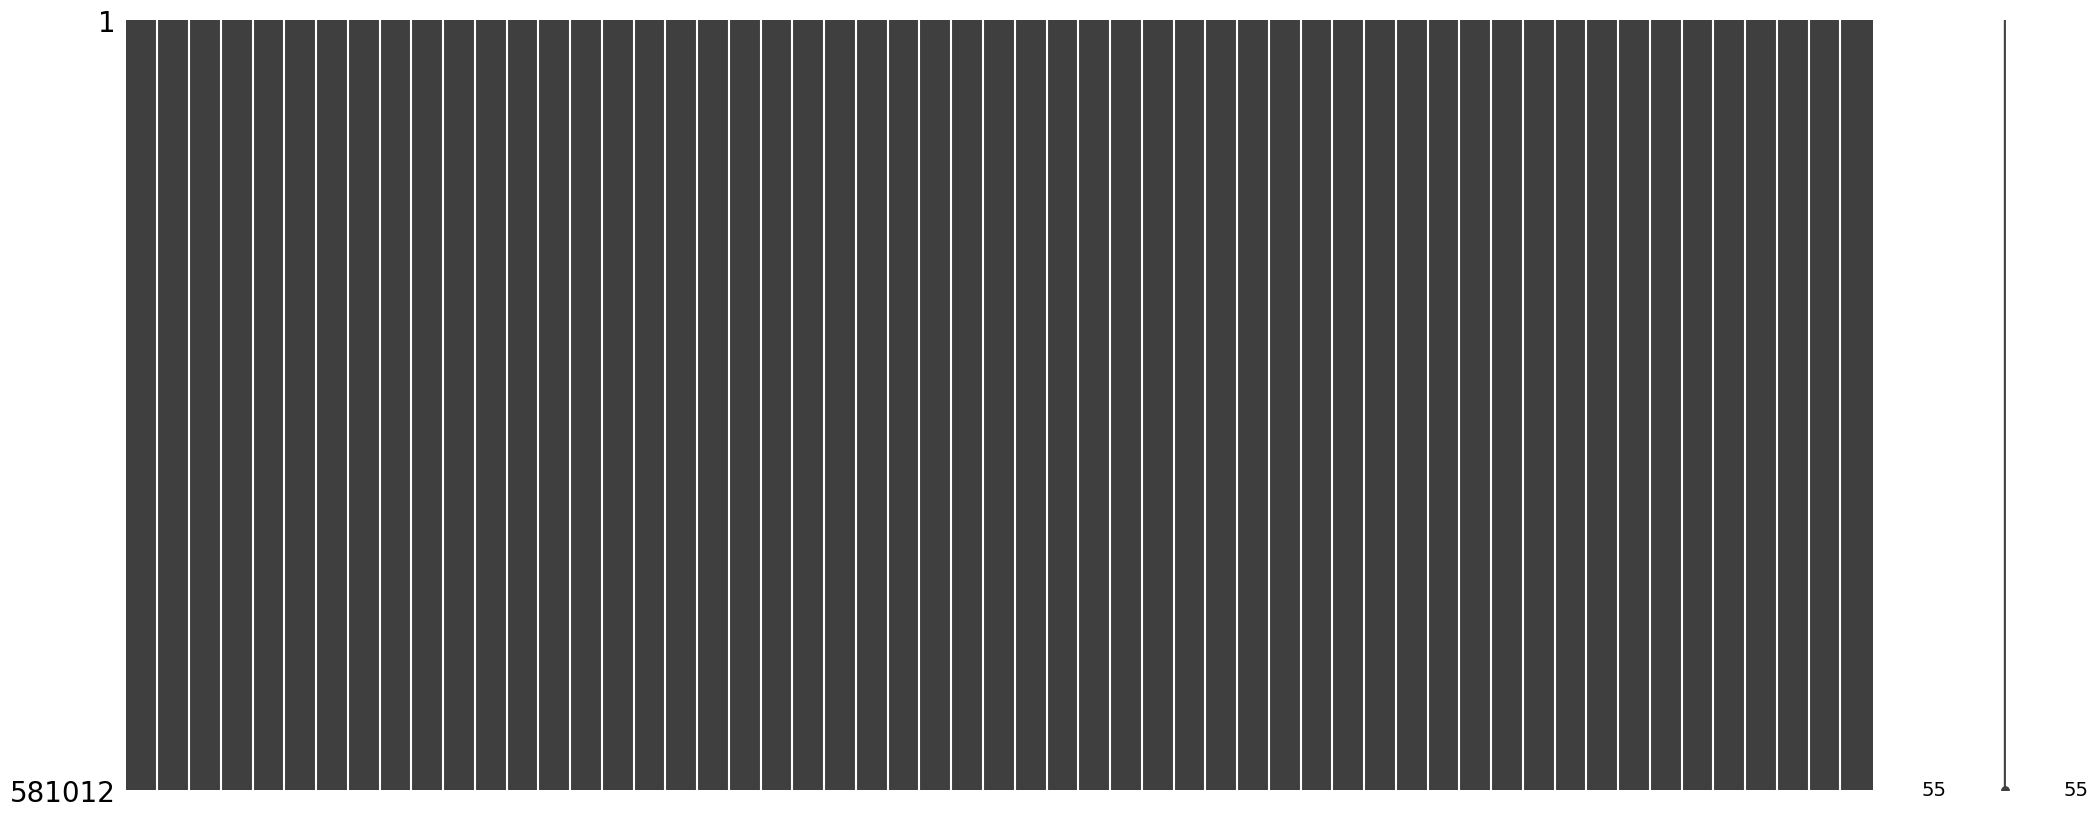

In [ ]:
# visualize missingness using msno
# --optional since there are no missingness show above--
import missingno as msno
msno.matrix(fct)

* dark: values present
* white space: missingness
* Conclusion: no missingness appear!

In [ ]:
# check for duplicates
print('Duplicate:', fct.duplicated().sum())

Duplicate: 0


In [ ]:
# check for all statistical informations:
fct.describe()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
count,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,...,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000
mean,2959.365301,155.656807,14.103704,269.428217,46.418855,2350.146611,212.146049,223.318716,142.528263,1980.291226,...,0.090392,0.077716,0.002773,0.003255,0.000205,0.000513,0.026803,0.023762,0.015060,2.051471
std,279.984734,111.913721,7.488242,212.549356,58.295232,1559.254870,26.769889,19.768697,38.274529,1324.195210,...,0.286743,0.267725,0.052584,0.056957,0.014310,0.022641,0.161508,0.152307,0.121791,1.396504
min,1859.000000,0.000000,0.000000,0.000000,-173.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2809.000000,58.000000,9.000000,108.000000,7.000000,1106.000000,198.000000,213.000000,119.000000,1024.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,2996.000000,127.000000,13.000000,218.000000,30.000000,1997.000000,218.000000,226.000000,143.000000,1710.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,3163.000000,260.000000,18.000000,384.000000,69.000000,3328.000000,231.000000,237.000000,168.000000,2550.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
max,3858.000000,360.000000,66.000000,1397.000000,601.000000,7117.000000,254.000000,254.000000,254.000000,7173.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000


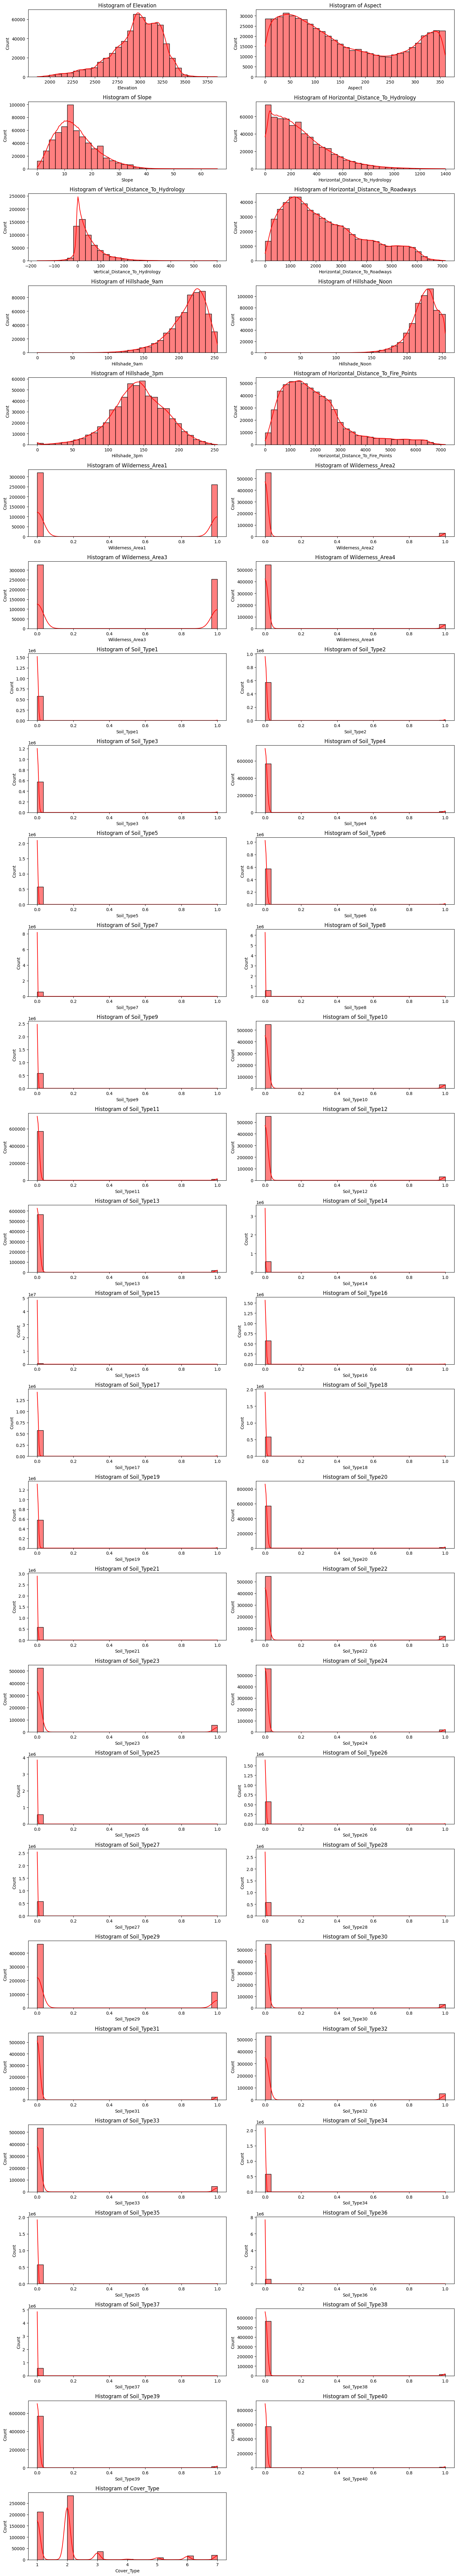

In [ ]:
# Using histogram/bar graph visualization
cols = fct.columns
n_features = len(cols)

# Calculate the number of rows needed based on the number of features and columns per row
n_cols_per_row = 2
n_rows = (n_features + n_cols_per_row - 1) // n_cols_per_row # Use integer division and ceiling

fig, axes = plt.subplots(n_rows, n_cols_per_row, figsize=(15, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(fct[col], bins=30, kde=True, ax=axes[i], color="red")
    axes[i].set_title(f"Histogram of {col}")

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

* Personally I think histogram would be the best choice to visualize the distribution in each column! It helps define the best characteristic of each catergory such as skewnes, outliers, etc.
* Cover_Type is the Target Variable!!
* Challenge: Since this is a large dataset, it took a long time to visualize all of the histogram distributions.

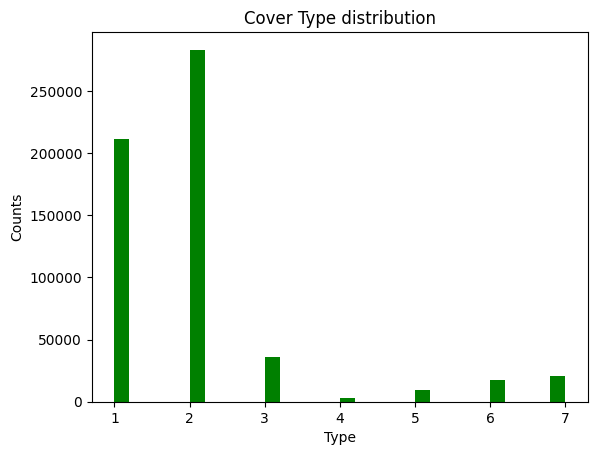

In [ ]:
# Target variable using Histogram plot
target_var = fct['Cover_Type'].dropna()

plt.figure()
plt.hist(target_var, bins=30, color='green')
plt.title('Cover Type distribution')
plt.xlabel('Type')
plt.ylabel('Counts')
plt.show()

In [ ]:
# check on value count of each target 'Cover Type' value
fct['Cover_Type'].value_counts()

,count
Cover_Type,
2,283301
1,211840
3,35754
7,20510
6,17367
5,9493
4,2747


In [ ]:
fct = df.dropna()
print("\nDataFrame after dropping rows with any missing values:")
print(fct)


DataFrame after dropping rows with any missing values:
       Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  \
0           2596      51      3                               258   
1           2590      56      2                               212   
2           2804     139      9                               268   
3           2785     155     18                               242   
4           2595      45      2                               153   
...          ...     ...    ...                               ...   
37871       3060       0     11                               624   
37872       3060      15     11                               600   
37873       3057      30      9                               576   
37874       3054      75      9                               553   
37875       3047      94     10                               531   

       Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
0                                   0    

In [ ]:
print(fct.isna().sum())

Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Wilderness_Area1                      0
Wilderness_Area2                      0
Wilderness_Area3                      0
Wilderness_Area4                      0
Soil_Type1                            0
Soil_Type2                            0
Soil_Type3                            0
Soil_Type4                            0
Soil_Type5                            0
Soil_Type6                            0
Soil_Type7                            0
Soil_Type8                            0
Soil_Type9                            0
Soil_Type10                           0
Soil_Type11                           0
